<a href="https://colab.research.google.com/github/jaewoo0108/ml/blob/main/week07-bias-variance/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 - Bias & Variance(모델 diagnostic)

- 훈련 세트,검증 세트,테스트 세트
- high bias와 high variance로 모델 평가, lambda와의 관계


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split # 데이터를 무작위로 나눠주는 함수

# 2차 곡선인 데이터 만들기(전체 예제가 150개, 입력 특성이 1개인 데이터)
np.random.seed(0)
m = 150
X = np.random.uniform(-4, 4, size=(m, 1))
y = 0.5 * X[:,0]**2 + X[:,0] + 3 + np.random.normal(0, 3.0, size=m)

# 데이터셋을 train,cross validation,test 세트로 (6:2:2 3등분)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state = 1)
X_cv, X_test, y_cv, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state = 1)

print(f"훈련 {len(X_train)}개 / 검증 {len(X_cv)}개 / 테스트 {len(X_test)}개")


훈련 90개 / 검증 30개 / 테스트 30개


In [ ]:
# 평가용 오차는 정규화항을 빼고 오차항만 계산한다!!
from sklearn.metrics import mean_squared_error

def compute_cost(y_true, y_pred):
  m = len(y_true)
  return np.sum((y_true - y_pred)** 2 / (2 * m))

a = np.array([1.0, 2.0, 3.0])
b = np.array([1.5, 2.0, 2.0])
print("직접 구현 :", compute_cost(a,b))
print("sklearn / 2 :", mean_squared_error(a,b) / 2)

직접 구현 : 0.20833333333333331
sklearn / 2 : 0.20833333333333334


In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge

# 여러 degree 별로 다항 회귀를 학습하고 (훈련오차, 검증오차)를 돌려주는 함수
# lambda_ = 0이면 정구화 없음, 0보다 크면 Ridge로 정규화
def fit_and_evaluate(degree, X_tr, y_tr, X_val, y_val, lambda_ = 0.0):
  # 기존의 데이터들을 다항 회귀에 적용 가능한 다항 특성으로 만든다
  poly = PolynomialFeatures(degree=degree, include_bias=False)
  X_tr_p = poly.fit_transform(X_tr)
  X_val_p = poly.transform(X_val)

  # 데이터들간의 정규화 과정(숫자 크기 맞추기)
  scaler = StandardScaler()
  X_tr_s = scaler.fit_transform(X_tr_p)
  X_val_s = scaler.transform(X_val_p)

  model = LinearRegression() if lambda_ == 0 else Ridge(alpha = lambda_)
  model.fit(X_tr_s, y_tr) # 파라미터 w,b는 훈련세트로만 학습한다

  j_train = compute_cost(y_tr, model.predict(X_tr_s))
  j_cv = compute_cost(y_val, model.predict(X_val_s))
  return j_train, j_cv

for d in [1, 3, 10]:
  jt, jv = fit_and_evaluate(d, X_train, y_train, X_cv, y_cv)
  print(f"차수 {d:2d} -> J_train={jt:.3f}, J_cv={jv:.3f}")

차수  1 -> J_train=6.959, J_cv=8.409
차수  3 -> J_train=3.717, J_cv=4.438
차수 10 -> J_train=3.491, J_cv=4.987


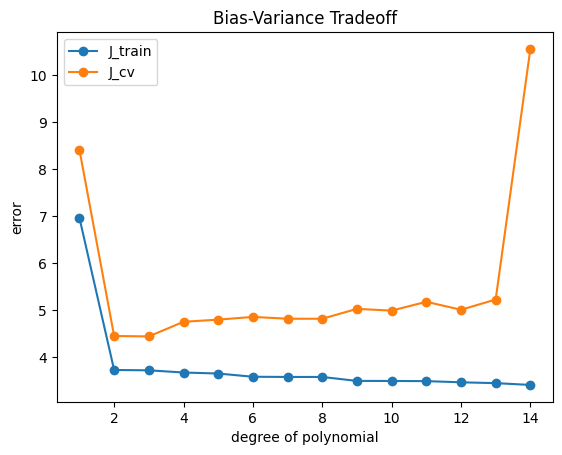

In [ ]:
# degress를 늘려가면서 J_train, J_cv 기록
degrees = range(1,15)
j_train_list, j_cv_list = [], []

for d in degrees:
  jt, jv = fit_and_evaluate(d, X_train, y_train, X_cv, y_cv)
  j_train_list.append(jt)
  j_cv_list.append(jv)


# 두 오차의 곡선 그리기
plt.plot(degrees, j_train_list, marker="o", label="J_train")
plt.plot(degrees, j_cv_list, marker="o", label="J_cv")
plt.xlabel("degree of polynomial")
plt.ylabel("error")
plt.legend()
plt.title("Bias-Variance Tradeoff")
plt.show()

In [ ]:
# 검증 오차가 가장 낮은 degree를 선택
best_degree = list(degrees)[np.argmin(j_cv_list)]
print("선택된 차수:",best_degree)

# 선택한 degree로 훈련/검증 오차 확인
j_train, j_cv = fit_and_evaluate(best_degree, X_train, y_train, X_cv, y_cv)

poly = PolynomialFeatures(degree=best_degree, include_bias=False)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(poly.fit_transform(X_train))
model = LinearRegression().fit(X_tr_s, y_train)
X_test_s = scaler.transform(poly.transform(X_test))
j_test = compute_cost(y_test, model.predict(X_test_s))

# train, cross validation, test 세트의 오차값
print(f"J_train={j_train:.3f}, J_cv={j_cv:.3f}, J_test={j_test:.3f}")


선택된 차수: 3
J_train=3.717, J_cv=4.438, J_test=3.300


J_train: [3.514  3.5551 3.5793 3.6118 3.7161 4.446  6.9944 9.8475]
J_cv   : [4.8477 4.7997 4.7951 4.7622 4.9895 6.0358 8.1411 9.9868]


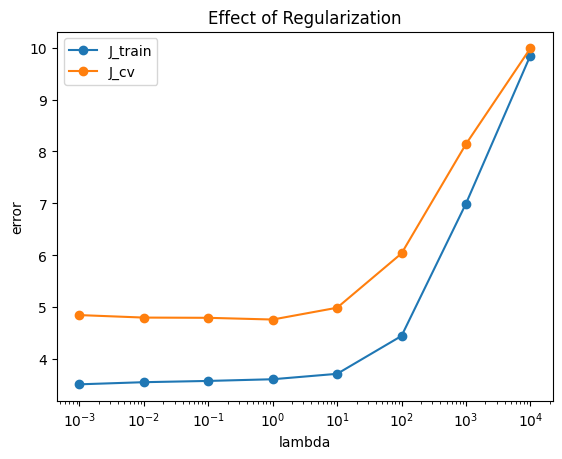

In [ ]:
# lambda가 bias-variance에 주는 영향

lambdas = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
j_train_list, j_cv_list = [], []

for lam in lambdas:
  jt, jv = fit_and_evaluate(10, X_train, y_train, X_cv, y_cv, lambda_=lam)
  j_train_list.append(jt)
  j_cv_list.append(jv)

print("J_train:", np.round(j_train_list, 4))
print("J_cv   :", np.round(j_cv_list, 4))

plt.plot(lambdas, j_train_list, marker="o", label="J_train")
plt.plot(lambdas, j_cv_list, marker="o", label="J_cv")
plt.xscale("log")
plt.xlabel("lambda")
plt.ylabel("error")
plt.legend()
plt.title("Effect of Regularization")
plt.show()
